<a href="https://colab.research.google.com/github/koshikdebanath/build-llm-from-scratch/blob/main/Build_LLM_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tokenizing Text

In [ ]:
import urllib.request
url = ("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch02/01_main-chapter-code/the-verdict.txt")

file_path = "the-verdict.txt"
urllib.request.urlretrieve(url, file_path)

('the-verdict.txt', <http.client.HTTPMessage at 0x799b61e2dee0>)

In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()

print("Total number of character: ", len(raw_text))
print(raw_text[:99])

Total number of character:  20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [ ]:
import re
text = "Hello, world. This is a test"
result = re.split(r'(\s)',text)
print(result)

['Hello,', ' ', 'world.', ' ', 'This', ' ', 'is', ' ', 'a', ' ', 'test']


In [ ]:
result = re.split(r'([,.]|\s)',text)
print(result)

['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ' ', 'is', ' ', 'a', ' ', 'test']


In [ ]:
result = [item for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'This', 'is', 'a', 'test']


In [ ]:
text = "Hello, world. Is this-- a test?"
result = re.split(r'([,.:;?_!"()\']|--|\s)',text)
result = [item.strip() for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


### Now apply on the `Edith Wharton's` Book

In [ ]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)',raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(f"The length of the tokenized list is: {len(preprocessed)}")

The length of the tokenized list is: 4690


In [ ]:
print("The first 30 tokens: ", preprocessed[:30])

The first 30 tokens:  ['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


### Converting tokens into token IDs

In [ ]:
# Fist build a vocabulary
all_words = sorted(set(preprocessed))
vocab_size = len(all_words)
print("First 10 items from the vocabulary: ", all_words[:10])
print("The length of the vocab: ", vocab_size)

First 10 items from the vocabulary:  ['!', '"', "'", '(', ')', ',', '--', '.', ':', ';']
The length of the vocab:  1130


In [ ]:
# Creating a vocabulary
vocab = {token:integer for integer, token in enumerate(all_words)}
# Print first 51 entries of the vocabulary
for id, item in enumerate(vocab.items()):
  print(f"Item : {item[0]}, Token ID : {id}")
  if id >= 50:
    break

Item : !, Token ID : 0
Item : ", Token ID : 1
Item : ', Token ID : 2
Item : (, Token ID : 3
Item : ), Token ID : 4
Item : ,, Token ID : 5
Item : --, Token ID : 6
Item : ., Token ID : 7
Item : :, Token ID : 8
Item : ;, Token ID : 9
Item : ?, Token ID : 10
Item : A, Token ID : 11
Item : Ah, Token ID : 12
Item : Among, Token ID : 13
Item : And, Token ID : 14
Item : Are, Token ID : 15
Item : Arrt, Token ID : 16
Item : As, Token ID : 17
Item : At, Token ID : 18
Item : Be, Token ID : 19
Item : Begin, Token ID : 20
Item : Burlington, Token ID : 21
Item : But, Token ID : 22
Item : By, Token ID : 23
Item : Carlo, Token ID : 24
Item : Chicago, Token ID : 25
Item : Claude, Token ID : 26
Item : Come, Token ID : 27
Item : Croft, Token ID : 28
Item : Destroyed, Token ID : 29
Item : Devonshire, Token ID : 30
Item : Don, Token ID : 31
Item : Dubarry, Token ID : 32
Item : Emperors, Token ID : 33
Item : Florence, Token ID : 34
Item : For, Token ID : 35
Item : Gallery, Token ID : 36
Item : Gideon, Token 

In [ ]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)

        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuations
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

In [ ]:
tokenizer = SimpleTokenizerV1(vocab)
text = """"It's the last he painted, you know,"
       Mrs. Gisburn said with pardonable pride."""

ids = tokenizer.encode(text)
print(ids)

[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [ ]:
tokenizer.decode(ids)

'" It\' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.'

In [ ]:
text = "Hello, do you like tea?"
tokenizer.encode(text)

KeyError: 'Hello'

### Adding special context tokens

In [ ]:
all_tokens = list(set(preprocessed))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])
vocab = {token:integer for integer, token in enumerate(all_tokens)}
print(f"The length of vocab: {len(vocab)}")

The length of vocab: 1132


In [ ]:
for i, item in enumerate(list(vocab.items())[-5:]):
  print(item)

('luncheon-table', 1127)
('lean', 1128)
('see', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


In [ ]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)

        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        preprocessed = [
            item if item in self.str_to_int else "<|unk|>" for item in preprocessed
        ]

        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuations
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

In [ ]:
text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."
text = " <|endoftext|> ".join([text1, text2])
print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


In [ ]:
tokenizer = SimpleTokenizerV2(vocab)
print(tokenizer.encode(text))

[1131, 551, 720, 411, 53, 816, 1093, 1130, 263, 86, 355, 1073, 852, 86, 1131, 1050]


In [ ]:
print(tokenizer.decode(tokenizer.encode(text)))

<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.


### Byte pair encoding(BPE)

In [ ]:
!uv pip install tiktoken

Using Python 3.12.12 environment at: /usr
Audited 1 package in 255ms


In [ ]:

from importlib.metadata import version
import tiktoken
print(f"Tiktoken version: {version("tiktoken")}")

Tiktoken version: 0.12.0


In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")

In [ ]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
    "of someunknownPlace."
)

integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


In [ ]:
strings = tokenizer.decode(integers)
print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


In [ ]:
ids = tokenizer.encode("Akwirw ier")
print(ids)

[33901, 86, 343, 86, 220, 959]


In [ ]:
print(tokenizer.decode(tokenizer.encode("Akwirw ier")))

Akwirw ier


In [ ]:
for id in ids:
  print(tokenizer.decode([id]))

Ak
w
ir
w
 
ier


### Data sampling with a sliding window

In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [ ]:
enc_sample = enc_text[50:]
print(len(enc_sample))

5095


In [ ]:
enc_sample[:10]

[290, 4920, 2241, 287, 257, 4489, 64, 319, 262, 34686]

In [ ]:
context_size = 4

x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]
print(f"x: {x}")
print(f"y:        {y}")

x: [290, 4920, 2241, 287]
y:        [4920, 2241, 287, 257]


In [ ]:
for i in range(1, context_size+1):
  context = enc_sample[:i]
  desired = enc_sample[i]
  print(context, "------->", desired)

[290] -------> 4920
[290, 4920] -------> 2241
[290, 4920, 2241] -------> 287
[290, 4920, 2241, 287] -------> 257


In [ ]:
for i in range(1, context_size+1):
  context = enc_sample[:i]
  desired = enc_sample[i]
  print(tokenizer.decode(context), "------->", tokenizer.decode([desired]))

 and ------->  established
 and established ------->  himself
 and established himself ------->  in
 and established himself in ------->  a


In [ ]:
import torch

In [ ]:
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
  def __init__(self, text, tokenizer, max_length, stride):
    self.input_ids = []
    self.target_ids = []

    token_ids = tokenizer.encode(text)

    for i in range(0, len(token_ids) - max_length, stride):
      input_chunk = token_ids[i:i+max_length]
      output_chunk = token_ids[i+1:i+max_length+1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(output_chunk))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.target_ids[idx]

In [ ]:
def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128,
                         shuffle=True, drop_last=True,
                         num_workers=0):
  tokenizer = tiktoken.get_encoding("gpt2")
  dataset = GPTDatasetV1(txt,tokenizer, max_length, stride)
  dataloader = DataLoader(
      dataset,
      batch_size=batch_size,
      shuffle=shuffle,
      drop_last=drop_last, # drop_last=True drops the last batch if it is shorter than the specified batch_size to prevent loss spikes during training.
      num_workers=num_workers
  )
  return dataloader

In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()

dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False
)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


In [ ]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]


In [ ]:
batch_size = 1
max_length = 4
stride = 2
dataloader = create_dataloader_v1(
    raw_text, batch_size=batch_size, max_length=max_length, stride=stride, shuffle=False
)

print(f"Batch Size: {batch_size}, Max Length: {max_length}, Stride: {stride}")
data_iter = iter(dataloader)
first_batch = next(data_iter)
print("First Batch is: ", first_batch)

second_batch = next(data_iter)
print("Second Batch is: ", second_batch)

Batch Size: 1, Max Length: 4, Stride: 2
First Batch is:  [tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]
Second Batch is:  [tensor([[2885, 1464, 1807, 3619]]), tensor([[1464, 1807, 3619,  402]])]


In [ ]:
batch_size = 1
max_length = 2
stride = 2
dataloader = create_dataloader_v1(
    raw_text, batch_size=batch_size, max_length=max_length, stride=stride, shuffle=False
)

print(f"Batch Size: {batch_size}, Max Length: {max_length}, Stride: {stride}")
data_iter = iter(dataloader)
first_batch = next(data_iter)
print("First Batch is: ", first_batch)

second_batch = next(data_iter)
print("Second Batch is: ", second_batch)

Batch Size: 1, Max Length: 2, Stride: 2
First Batch is:  [tensor([[ 40, 367]]), tensor([[ 367, 2885]])]
Second Batch is:  [tensor([[2885, 1464]]), tensor([[1464, 1807]])]


In [ ]:
batch_size = 1
max_length = 8
stride = 2
dataloader = create_dataloader_v1(
    raw_text, batch_size=batch_size, max_length=max_length, stride=stride, shuffle=False
)

print(f"Batch Size: {batch_size}, Max Length: {max_length}, Stride: {stride}")
data_iter = iter(dataloader)
first_batch = next(data_iter)
print("First Batch is: ", first_batch)

second_batch = next(data_iter)
print("Second Batch is: ", second_batch)

Batch Size: 1, Max Length: 8, Stride: 2
First Batch is:  [tensor([[  40,  367, 2885, 1464, 1807, 3619,  402,  271]]), tensor([[  367,  2885,  1464,  1807,  3619,   402,   271, 10899]])]
Second Batch is:  [tensor([[ 2885,  1464,  1807,  3619,   402,   271, 10899,  2138]]), tensor([[ 1464,  1807,  3619,   402,   271, 10899,  2138,   257]])]


In [ ]:
batch_size = 2
max_length = 2
stride = 2
dataloader = create_dataloader_v1(
    raw_text, batch_size=batch_size, max_length=max_length, stride=stride, shuffle=False
)

print(f"Batch Size: {batch_size}, Max Length: {max_length}, Stride: {stride}")
data_iter = iter(dataloader)
first_batch = next(data_iter)
print("First Batch is: ", first_batch)

second_batch = next(data_iter)
print("Second Batch is: ", second_batch)

Batch Size: 2, Max Length: 2, Stride: 2
First Batch is:  [tensor([[  40,  367],
        [2885, 1464]]), tensor([[ 367, 2885],
        [1464, 1807]])]
Second Batch is:  [tensor([[1807, 3619],
        [ 402,  271]]), tensor([[ 3619,   402],
        [  271, 10899]])]


In [ ]:
batch_size = 2
max_length = 4
stride = 2
dataloader = create_dataloader_v1(
    raw_text, batch_size=batch_size, max_length=max_length, stride=stride, shuffle=False
)

print(f"Batch Size: {batch_size}, Max Length: {max_length}, Stride: {stride}")
data_iter = iter(dataloader)
first_batch = next(data_iter)
print("First Batch is: ", first_batch)

second_batch = next(data_iter)
print("Second Batch is: ", second_batch)

Batch Size: 2, Max Length: 4, Stride: 2
First Batch is:  [tensor([[  40,  367, 2885, 1464],
        [2885, 1464, 1807, 3619]]), tensor([[ 367, 2885, 1464, 1807],
        [1464, 1807, 3619,  402]])]
Second Batch is:  [tensor([[ 1807,  3619,   402,   271],
        [  402,   271, 10899,  2138]]), tensor([[ 3619,   402,   271, 10899],
        [  271, 10899,  2138,   257]])]


In [ ]:
batch_size = 8
max_length = 4
stride = 4
dataloader = create_dataloader_v1(
    raw_text, batch_size=batch_size, max_length=max_length, stride=stride, shuffle=False
)

print(f"Batch Size: {batch_size}, Max Length: {max_length}, Stride: {stride}")
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("First Batch is: \n")
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

inputs, targets = next(data_iter)
print("Second Batch is: \n")
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Batch Size: 8, Max Length: 4, Stride: 4
First Batch is: 

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])
Second Batch is: 

Inputs:
 tensor([[  287,   262,  6001,   286],
        [  465, 13476,    11,   339],
        [  550,  5710,   465, 12036],
        [   11,  6405,   257,  5527],
        [27075,    11,   290,  4920],
        [ 2241,   287,   257,  4489],
        [   64,   319,   262, 34686],
        [41976,   

### Creating token embeddings

In [ ]:
import torch
input_ids = torch.tensor([2,3,5,1])
vocab_size = 6
output_dim = 3
torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(
    vocab_size, output_dim
)
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [ ]:
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


In [ ]:
print(f"Embedding of the input_ids\n")
print(embedding_layer(input_ids))

Embedding of the input_ids

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


### Encoding word positions

We have two kinds of positioanl encoding:
1. Relative Positional Embedding
2. Absolute Positional Embedding

In [ ]:
vocab_size = 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(
    vocab_size, output_dim
)

max_length = 4
dataloader = create_dataloader_v1(
    raw_text,batch_size=8, max_length=max_length, stride=max_length,
    shuffle=False
)

data_iter = iter(dataloader)
inputs , targets = next(data_iter)
print("Token IDs:\n", inputs)
print("\nInputs Shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs Shape:
 torch.Size([8, 4])


In [ ]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


In [ ]:
token_embeddings[0]

tensor([[ 0.3045, -2.2610, -0.4094,  ..., -1.6522, -0.2868,  1.2438],
        [-0.2460,  0.2528,  0.2237,  ..., -0.7093, -0.6564, -1.2014],
        [ 0.4986,  0.1621,  0.6822,  ...,  1.1171,  0.2367,  0.2138],
        [-0.5436,  0.6707,  2.0537,  ..., -0.6127,  0.5454, -0.9175]],
       grad_fn=<SelectBackward0>)

In [ ]:
token_embeddings[0].shape

torch.Size([4, 256])

In [ ]:
torch.arange(4)

tensor([0, 1, 2, 3])

In [ ]:
print(token_embedding_layer.weight.shape)

torch.Size([50257, 256])


In [ ]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(
    context_length, output_dim
) # (4,256)
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
print(pos_embeddings.shape) # (4,256)

torch.Size([4, 256])


In [ ]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])


# Coding Attention Mechanism

Self Attention Types:
>
Simplified Self Attention -> Self-attention -> Causal attention -> Multi-head attention

In [1]:
import torch

# Your journey starts with one step

inputs = torch.tensor(
    [
        [0.43, 0.15, 0.89], # Your     (x^1)
        [0.55 , 0.87, 0.66], # journey (x^2)
        [0.57 , 0.85, 0.64], # starts  (x^3)
        [0.22 , 0.58, 0.33], # with    (x^4)
        [0.77 , 0.25, 0.10], # one     (x^5)
        [0.05 , 0.80, 0.55], # step    (x^6)
    ]
)

query = inputs[1] # journey

print("Inputs shape: ", inputs.shape)

attention_scores_2 = torch.empty(inputs.shape[0])

for i, x_i in enumerate(inputs):
  attention_scores_2[i] = torch.dot(x_i, query) # dot product of query and each input tokens

print(attention_scores_2)

Inputs shape:  torch.Size([6, 3])
tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [2]:
# Now normalize the attention scores to get the attention weights

attention_weights_2_tmp = attention_scores_2/attention_scores_2.sum()
print("Attention weights: ", attention_weights_2_tmp)
print("Sum: ", attention_weights_2_tmp.sum())

Attention weights:  tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum:  tensor(1.0000)


That means:

- query("journey"): will pay 14.55 % attention to "Your", 22.78% to itself("journey"), 22.49% to "starts" and so on...

In [3]:
def softmanx_naive(x):
  return torch.exp(x) / torch.exp(x).sum(dim=0)

attention_weights_2_naive = softmanx_naive(attention_scores_2)
print("Attention weights: ", attention_weights_2_naive)
print("Sum: ", attention_weights_2_naive.sum())

Attention weights:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum:  tensor(1.)


In [4]:
attention_weights_2 = torch.softmax(attention_scores_2, dim=0)
print("Attention weights: ", attention_weights_2)
print("Sum: ", attention_weights_2.sum())

Attention weights:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum:  tensor(1.)


In [5]:
query = inputs[1]
print("The query is: ", query)
context_vec_2 = torch.zeros(query.shape)
print("Context vec for query 2: ", context_vec_2)
print(10*"-----")
for i, x_i in enumerate(inputs):
  print(f"The {i}th attention weight: {attention_weights_2[i]}")
  print(f"The {i}th input vector: {x_i}")
  context_vec_2 += attention_weights_2[i] * x_i
  print("Multiplication of: attention_weight and input: ", attention_weights_2[i] * x_i)
  print("The context vec(2) is: ", context_vec_2)
  print(10*"-----")

print("After computing contect vec: ", context_vec_2)

The query is:  tensor([0.5500, 0.8700, 0.6600])
Context vec for query 2:  tensor([0., 0., 0.])
--------------------------------------------------
The 0th attention weight: 0.13854756951332092
The 0th input vector: tensor([0.4300, 0.1500, 0.8900])
Multiplication of: attention_weight and input:  tensor([0.0596, 0.0208, 0.1233])
The context vec(2) is:  tensor([0.0596, 0.0208, 0.1233])
--------------------------------------------------
The 1th attention weight: 0.2378913015127182
The 1th input vector: tensor([0.5500, 0.8700, 0.6600])
Multiplication of: attention_weight and input:  tensor([0.1308, 0.2070, 0.1570])
The context vec(2) is:  tensor([0.1904, 0.2277, 0.2803])
--------------------------------------------------
The 2th attention weight: 0.23327402770519257
The 2th input vector: tensor([0.5700, 0.8500, 0.6400])
Multiplication of: attention_weight and input:  tensor([0.1330, 0.1983, 0.1493])
The context vec(2) is:  tensor([0.3234, 0.4260, 0.4296])
------------------------------------

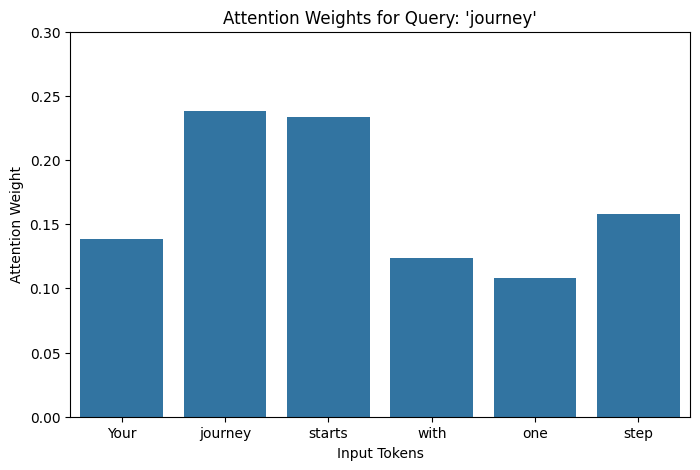

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define labels for the input tokens for better visualization
labels = ["Your", "journey", "starts", "with", "one", "step"]

# Create a bar plot for attention weights
plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=attention_weights_2.detach().numpy())
plt.title("Attention Weights for Query: 'journey'")
plt.xlabel("Input Tokens")
plt.ylabel("Attention Weight")
plt.ylim(0, 0.3) # Set y-axis limit to clearly see the differences
plt.show()

In [7]:
query = inputs[0] # Your

attention_scores_0 = torch.empty(inputs.shape[0])

for i, x_i in enumerate(inputs):
  attention_scores_0[i] = torch.dot(x_i, query) # dot product of query and each input tokens

attention_weights_0 = torch.softmax(attention_scores_0, dim=0)

print("Attention weights for query 'Your': ", attention_weights_0)

Attention weights for query 'Your':  tensor([0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452])


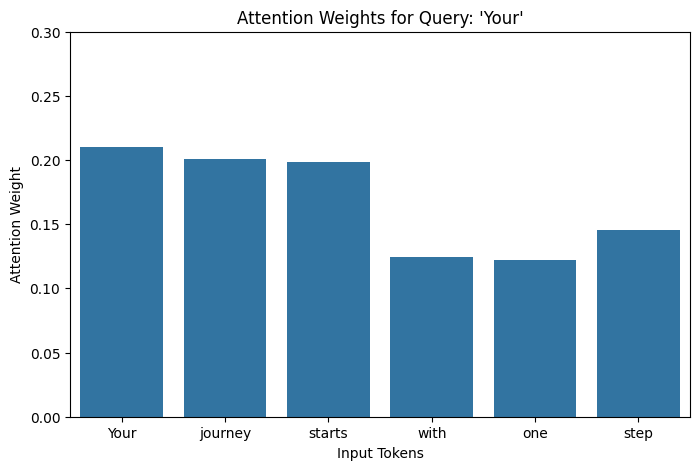

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=attention_weights_0.detach().numpy())
plt.title("Attention Weights for Query: 'Your'")
plt.xlabel("Input Tokens")
plt.ylabel("Attention Weight")
plt.ylim(0, 0.3) # Set y-axis limit to clearly see the differences
plt.show()

In [9]:
attn_scores = torch.empty(6,6)
for i, x_i in enumerate(inputs):
  for j, x_j in enumerate(inputs):
    attn_scores[i,j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [10]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [11]:
attn_weights = attn_scores.softmax(dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [12]:
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
print("Row 2 sum:", row_2_sum)
print("All row sums: ", attn_weights.sum(dim=-1))

Row 2 sum: 1.0
All row sums:  tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


<Axes: >

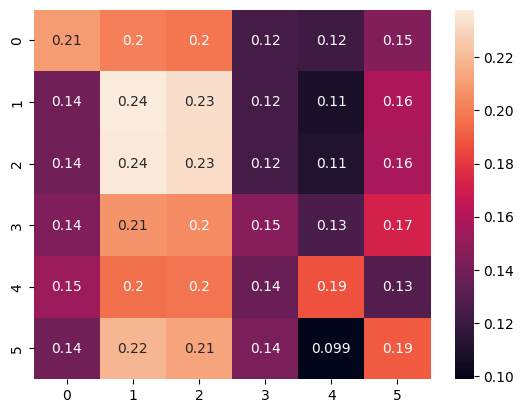

In [13]:
import seaborn as sns
sns.heatmap(attn_weights, annot=True)

In [14]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


In [15]:
print("Previous 2nd context vector", context_vec_2)

Previous 2nd context vector tensor([0.4419, 0.6515, 0.5683])


In [16]:
x_2 = inputs[1] # [0.55 , 0.87, 0.66], # journey (x^2)
d_in = inputs.shape[1] # 3
d_out = 2

In [17]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [18]:
W_query.shape

torch.Size([3, 2])

In [19]:
W_query

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])

In [20]:
query_2 = x_2 @ W_query
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value
print(query_2)

tensor([0.4306, 1.4551])


In [21]:
keys = inputs @ W_key
values = inputs @ W_value
print("keys.shape:", keys.shape)
print("values.shape:", values.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


In [22]:
keys_2 = keys[1]
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(1.8524)


In [23]:
attn_scores_2 = query_2 @ keys.T
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [24]:
d_k = keys.shape[-1]
print("d_k:",d_k)
attn_weights_2 = torch.softmax(attn_scores_2 /  d_k**0.5, dim=-1)
print(attn_weights_2)

d_k: 2
tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


In [25]:
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


In [26]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):
  def __init__(self, d_in, d_out):
    super().__init__()
    self.W_query = nn.Parameter(torch.rand(d_in, d_out))
    self.W_key = nn.Parameter(torch.rand(d_in, d_out))
    self.W_value = nn.Parameter(torch.rand(d_in, d_out))

  def forward(self,x):
    keys = x @ self.W_key
    queries = x @ self.W_query
    values = x @ self.W_value

    attn_scores = queries @ keys.T # omega
    attn_weights = torch.softmax(
        attn_scores / keys.shape[-1] ** 0.5, dim=-1
    )

    context_vec = attn_weights @ values
    return context_vec

In [27]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out) # (3,2)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [28]:
class SelfAttention_v2(nn.Module):
  def __init__(self, d_in, d_out, qkv_bias=False):
    super().__init__()
    self.W_query = nn.Linear(d_in, d_out, bias=False)
    self.W_key = nn.Linear(d_in, d_out, bias=False)
    self.W_value = nn.Linear(d_in, d_out, bias=False)

  def forward(self,x):
    queries = self.W_query(x)
    keys = self.W_key(x)
    values = self.W_value(x)

    attn_scores = queries @ keys.T
    attn_weights = torch.softmax(
        attn_scores / keys.shape[0] ** 0.5, dim=-1
    )
    context_vec = attn_weights @ values

    return context_vec



In [29]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in,d_out)
print(sa_v2(inputs))

tensor([[-0.0752,  0.0693],
        [-0.0757,  0.0688],
        [-0.0758,  0.0687],
        [-0.0765,  0.0676],
        [-0.0767,  0.0673],
        [-0.0761,  0.0682]], grad_fn=<MmBackward0>)


In [30]:
sa_v1.W_key = torch.nn.Parameter(sa_v2.W_key.weight.T)
sa_v1.W_query = torch.nn.Parameter(sa_v2.W_query.weight.T)
sa_v1.W_value = torch.nn.Parameter(sa_v2.W_value.weight.T)

In [31]:
sa_v2(inputs)

tensor([[-0.0752,  0.0693],
        [-0.0757,  0.0688],
        [-0.0758,  0.0687],
        [-0.0765,  0.0676],
        [-0.0767,  0.0673],
        [-0.0761,  0.0682]], grad_fn=<MmBackward0>)

### Hiding future words with causal attention

In [32]:
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [33]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [34]:
masked_simple = attn_weights * mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


In [35]:
row_sums = masked_simple.sum(dim=-1, keepdim=False)
print(row_sums)
row_sums = masked_simple.sum(dim=-1, keepdim=True)
print(row_sums)

tensor([0.1921, 0.3700, 0.5357, 0.6775, 0.8415, 1.0000],
       grad_fn=<SumBackward1>)
tensor([[0.1921],
        [0.3700],
        [0.5357],
        [0.6775],
        [0.8415],
        [1.0000]], grad_fn=<SumBackward1>)


In [36]:
# Normalize it
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


In [37]:
# Some notes about `torch.triu`
a = torch.rand(3,3)
print(a)

a = torch.triu(a , diagonal=1)
print(a)

b = torch.rand(5,6)
print(b)

b = torch.triu(b, diagonal=0) # by default
print(b)

c = torch.rand(4,5)
print(c)

c = torch.triu(c, diagonal=-1)
print(c)

tensor([[0.7662, 0.8018, 0.6371],
        [0.3464, 0.2020, 0.1266],
        [0.4615, 0.7050, 0.3849]])
tensor([[0.0000, 0.8018, 0.6371],
        [0.0000, 0.0000, 0.1266],
        [0.0000, 0.0000, 0.0000]])
tensor([[0.3085, 0.6775, 0.0966, 0.9746, 0.7144, 0.4761],
        [0.2971, 0.5419, 0.1202, 0.8331, 0.0724, 0.2255],
        [0.9237, 0.3019, 0.3471, 0.3413, 0.7002, 0.8480],
        [0.6090, 0.5569, 0.6404, 0.4334, 0.6541, 0.6886],
        [0.8701, 0.1221, 0.6405, 0.1291, 0.2718, 0.2805]])
tensor([[0.3085, 0.6775, 0.0966, 0.9746, 0.7144, 0.4761],
        [0.0000, 0.5419, 0.1202, 0.8331, 0.0724, 0.2255],
        [0.0000, 0.0000, 0.3471, 0.3413, 0.7002, 0.8480],
        [0.0000, 0.0000, 0.0000, 0.4334, 0.6541, 0.6886],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.2718, 0.2805]])
tensor([[0.6478, 0.0773, 0.5222, 0.2814, 0.8556],
        [0.9325, 0.1030, 0.5139, 0.8541, 0.4517],
        [0.1223, 0.0137, 0.6391, 0.8987, 0.7450],
        [0.4405, 0.1300, 0.6143, 0.5208, 0.6014]])
tensor([[0.

In [38]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
print(mask)

print(20*"===")
print("Attention Scores: ", attn_scores)
print(20*"===")
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])
Attention Scores:  tensor([[ 0.2899,  0.0716,  0.0760, -0.0138,  0.1344, -0.0511],
        [ 0.4656,  0.1723,  0.1751,  0.0259,  0.1771,  0.0085],
        [ 0.4594,  0.1703,  0.1731,  0.0259,  0.1745,  0.0090],
        [ 0.2642,  0.1024,  0.1036,  0.0186,  0.0973,  0.0122],
        [ 0.2183,  0.0874,  0.0882,  0.0177,  0.0786,  0.0144],
        [ 0.3408,  0.1270,  0.1290,  0.0198,  0.1290,  0.0078]],
       grad_fn=<MmBackward0>)
tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_

In [39]:
print("Keys: ", keys)
print(20*"===")
print("Keys Shape: ", keys.shape)
print(20*"===")
print(keys.shape[-1])
print(20*"===")
attn_weights = torch.softmax(masked / keys.shape[-1] ** 0.5 , dim=1)
print(attn_weights)

Keys:  tensor([[ 0.3147, -0.4016],
        [-0.0298, -0.4459],
        [-0.0170, -0.4262],
        [-0.1054, -0.2724],
        [ 0.2185,  0.0482],
        [-0.2258, -0.4782]], grad_fn=<MmBackward0>)
Keys Shape:  torch.Size([6, 2])
2
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [40]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
example = torch.ones(6,6)
print("Example: ", example)
print(20*"===")
print(dropout(example))

Example:  tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])
tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


In [41]:
torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


In [42]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch)
print(20*"===")
print(batch.shape)

tensor([[[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]]])
torch.Size([2, 6, 3])


In [47]:
class CausalAttention(nn.Module):
  def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
    super().__init__()
    self.d_out = d_out
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer(
        "mask",
        torch.triu(torch.ones(context_length, context_length), diagonal=1)
    )

  def forward(self, x):
    b , num_tokens , d_in = x.shape
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)

    attn_scores = queries @ keys.transpose(1,2)
    attn_scores.masked_fill_(
        self.mask.bool()[:num_tokens , :num_tokens], -torch.inf)

    attn_weights = torch.softmax(
        attn_scores / keys.shape[-1] ** 0.5, dim=-1
    )

    attn_weights = self.dropout(attn_weights)

    context_vec = attn_weights @ values

    return context_vec

In [48]:
torch.manual_seed(123)
context_length = batch.shape[1] # This is the number of tokens
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print("context_vecs.shape:", context_vecs.shape)

context_vecs.shape: torch.Size([2, 6, 2])


### Extending single-head attention to multi-head attention

In [49]:
class MultiHeadAttentionWrapper(nn.Module):
  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    self.heads = nn.ModuleList(
        [
            CausalAttention(d_in, d_out, context_length, dropout, qkv_bias)
            for _ in range(num_heads)
        ]
    )
  def forward(self, x):
    return torch.cat([
        head(x) for head in self.heads
    ], dim=-1)

In [52]:
torch.manual_seed(123)
context_length = batch.shape[1] # This is the number of tokens
print("The context length is: ", context_length)
d_in , d_out = 3 , 2
mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, dropout = 0.0 , num_heads = 2)
context_vecs = mha(batch)
print("contex_vecs.shape: ", context_vecs.shape)

The context length is:  6
contex_vecs.shape:  torch.Size([2, 6, 4])


In [53]:
print(context_vecs)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)


In [54]:
## Exercise: 3.2
torch.manual_seed(123)
context_length = batch.shape[1] # This is the number of tokens
print("The context length is: ", context_length)
d_in , d_out = 3 , 1
mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, dropout = 0.0 , num_heads = 2)
context_vecs = mha(batch)
print("contex_vecs.shape: ", context_vecs.shape)
print(context_vecs)

The context length is:  6
contex_vecs.shape:  torch.Size([2, 6, 2])
tensor([[[-0.5740,  0.2216],
         [-0.7320,  0.0155],
         [-0.7774, -0.0546],
         [-0.6979, -0.0817],
         [-0.6538, -0.0957],
         [-0.6424, -0.1065]],

        [[-0.5740,  0.2216],
         [-0.7320,  0.0155],
         [-0.7774, -0.0546],
         [-0.6979, -0.0817],
         [-0.6538, -0.0957],
         [-0.6424, -0.1065]]], grad_fn=<CatBackward0>)


In [69]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
        "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # number of dim per head
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                    diagonal=1)
        )
    def forward(self, x):
        b , num_tokens, d_in = x.shape # (2, 6, 2)
        keys = self.W_key(x)
        queries = self.W_value(x)
        values = self.W_value(x)

        print("===" * 50)

        print("Keys shape: ", keys.shape)
        print("Queries shape: ", queries.shape)
        print("Values shape: ", values.shape)

        print("===" * 50)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) #  (2, 6, 2, 1) -> same as the element of the keys tensor but with different dimention
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim) # (2, 6, 2, 1)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim) # (2, 6, 2 , 1)

        print("After the `view` operation the shapes are: ")
        print("Keys shape: ", keys.shape)
        print("Queries shape: ", queries.shape)
        print("Values shape: ", values.shape)

        print("===" * 50)

        keys = keys.transpose(1,2) # (2, 6, 2 , 1) -> (2, 2, 6, 1)
        queries = queries.transpose(1,2) # (2, 6, 2 , 1) -> (2, 2, 6, 1)
        values = values.transpose(1,2) # (2, 6, 2 , 1) -> (2, 2, 6, 1)

        print("After the `transpose` operation the shapes are: ")
        print("Keys shape: ", keys.shape)
        print("Queries shape: ", queries.shape)
        print("Values shape: ", values.shape)

        print("===" * 50)

        atten_scores = queries @ keys.transpose(2, 3) # (2, 2, 6, 1) * (2, 2, 1, 6) -> (2, 2, 6, 6)
        print("The shape of atten_scores: ", atten_scores.shape)

        print("===" * 50)

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        print("The mask_bool is: \n", mask_bool)
        print("The shape of the mask_bool is: ", mask_bool.shape)

        print("===" * 50)

        attn_scores.masked_fill_(mask_bool, -torch.inf)
        print("The attn_scores is after filling with inf values: \n", attn_scores)
        print("The shape of the attn_scores is: ", attn_scores.shape)

        print("===" * 50)

        print("Keys.shape[-1] is : ", keys.shape[-1])

        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1] ** 0.5, dim = -1
        )

        attn_weights = self.dropout(attn_weights)

        print("The attention weights after dropout is: \n", attn_weights)
        print("The shape of the attention weights is: ", attn_weights.shape)

        print("===" * 50)

        print("attn_weights @ values shape is: ", (attn_weights @ values).shape)

        print("===" * 50)

        context_vec = (attn_weights @ values).transpose(1,2)

        print("The shape of the context_vec is: ", context_vec.shape)
        print("context_vec: ", context_vec)

        print("===" * 50)

        context_vec = context_vec.contiguous().view( # combines heads, where self.d_out = self.num_heads * self.head_dim
            b, num_tokens, self.d_out
        )

        print("The shape of the context_vec is: ", context_vec.shape)
        print("context_vec: ", context_vec)

        print("===" * 50)

        context_vec = self.out_proj(context_vec)
        print("The shape of the context_vec is: ", context_vec.shape)
        print("context_vec: \n", context_vec)

        print("===" * 50)

        return context_vec

In [70]:
torch.manual_seed(123)
batch_size, context_length, d_in = batch.shape
d_out = 2
num_heads = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=num_heads)
print("Batch Size: ", batch_size)
print("Context Length: ", context_length)
print("d_in: ", d_in)
print("d_out: ", d_out)
print("num_heads: ",num_heads)
print("===" * 50)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape: ", context_vecs.shape)

Batch Size:  2
Context Length:  6
d_in:  3
d_out:  2
num_heads:  2
Keys shape:  torch.Size([2, 6, 2])
Queries shape:  torch.Size([2, 6, 2])
Values shape:  torch.Size([2, 6, 2])
After the `view` operation the shapes are: 
Keys shape:  torch.Size([2, 6, 2, 1])
Queries shape:  torch.Size([2, 6, 2, 1])
Values shape:  torch.Size([2, 6, 2, 1])
After the `transpose` operation the shapes are: 
Keys shape:  torch.Size([2, 2, 6, 1])
Queries shape:  torch.Size([2, 2, 6, 1])
Values shape:  torch.Size([2, 2, 6, 1])
The shape of atten_scores:  torch.Size([2, 2, 6, 6])
The mask_bool is: 
 tensor([[False,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True],
        [False, False, False, False,  True,  True],
        [False, False, False, False, False,  True],
        [False, False, False, False, False, False]])
The shape of the mask_bool is:  torch.Size([6, 6])
The attn_scores is after filling with inf values: 
 ten